In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1" # for debugging

import torch
import torch.nn as nn
import math
import numpy as np
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: mps


In [2]:
class Encoder(nn.Module):
    def __init__(self, d_model: int, max_seq_len: int):
        super().__init__()
        self.d_model = d_model
        self.max_seq_len = max_seq_len

        # Self-attention (bidirectional, no causal mask)
        self.qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.attn_out = nn.Linear(d_model, d_model)

        # Feed-forward
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model)
        )

        # Layer norms
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)

    def forward(self, x):
        # Bidirectional self-attention
        residual = x
        x = self.ln1(x)

        qkv = self.qkv_proj(x)
        q, k, v = qkv.chunk(3, dim=-1)

        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_model)
        attn = torch.softmax(attn, dim=-1)

        x = attn @ v
        x = self.attn_out(x)
        x = residual + x

        # Feed-forward
        x = x + self.ffn(self.ln2(x))

        return x

class Decoder(nn.Module):
    def __init__(self, d_model, max_seq_len):
        super().__init__()
        self.d_model = d_model
        self.max_seq_len = max_seq_len

        # Causal self-attention
        self.self_qkv_proj = nn.Linear(d_model, 3 * d_model)
        self.self_attn_out = nn.Linear(d_model, d_model)

        # Cross-attention to encoder
        self.cross_q_proj = nn.Linear(d_model, d_model)
        self.cross_kv_proj = nn.Linear(d_model, 2 * d_model)
        self.cross_attn_out = nn.Linear(d_model, d_model)

        # Feed-forward
        self.ffn = nn.Sequential(
            nn.Linear(d_model, 4 * d_model),
            nn.GELU(),
            nn.Linear(4 * d_model, d_model)
        )

        # Layer norms
        self.ln1 = nn.LayerNorm(d_model)
        self.ln2 = nn.LayerNorm(d_model)
        self.ln3 = nn.LayerNorm(d_model)

    def forward(self, x, encoder_output):
        batch_size, seq_len, _ = x.shape

        # Causal self-attention on decoder sequence
        residual = x
        x = self.ln1(x)

        qkv = self.self_qkv_proj(x)
        q, k, v = qkv.chunk(3, dim=-1)

        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_model)
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device), diagonal=1).bool()
        attn = attn.masked_fill(causal_mask, float('-inf'))
        attn = torch.softmax(attn, dim=-1)

        x = attn @ v
        x = self.self_attn_out(x)
        x = residual + x

        # Cross-attention to encoder output (no causal mask)
        residual = x
        x = self.ln2(x)

        q = self.cross_q_proj(x)  # Q from decoder
        kv = self.cross_kv_proj(encoder_output)  # K, V from encoder
        k, v = kv.chunk(2, dim=-1)

        attn = (q @ k.transpose(-2, -1)) / math.sqrt(self.d_model)
        attn = torch.softmax(attn, dim=-1)

        x = attn @ v
        x = self.cross_attn_out(x)
        x = residual + x

        # Feed-forward
        x = x + self.ffn(self.ln2(x))

        return x

class SimpleDequant(nn.Module):
    def __init__(self, max_seq_len: int, num_instruments: int):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.num_instruments = num_instruments
        self.d_model = num_instruments * 3 # HOV representation requires 3 values per instrument

        # Encoder and decoder blocks
        self.encoder = Encoder(
            d_model=self.d_model,
            max_seq_len=self.max_seq_len,
        )
        self.decoder = Decoder(
            d_model=self.d_model,
            max_seq_len=self.max_seq_len,
        )

        # Output projection
        self.output_proj = nn.Linear(self.d_model, self.d_model)
        self.sigmoid = nn.Sigmoid()
        self.tanh = nn.Tanh()

    def forward(self, encoder_input: torch.Tensor, decoder_input: torch.Tensor) -> torch.Tensor:
        batch_size, seq_len, num_instruments, hov_size = encoder_input.shape

        assert seq_len <= self.max_seq_len, "max_seq_len exceeded."
        assert num_instruments == self.num_instruments
        assert hov_size == 3

        # Flatten to d_model dimension
        encoder_flat = encoder_input.flatten(start_dim=2)
        decoder_flat = decoder_input.flatten(start_dim=2)

        # Encode the input sequence
        encoder_output: torch.Tensor = self.encoder(encoder_flat)

        # Decode with cross-attention to encoder
        y: torch.Tensor = self.decoder(decoder_flat, encoder_output)

        # Project and reshape
        y = self.output_proj(y)
        y = y.reshape(batch_size, seq_len, num_instruments, hov_size)

        # Apply different activations to hits, offsets, and velocities
        hits = self.sigmoid(y[..., 0:1])
        offsets = 0.5 * self.tanh(y[..., 1:2])
        velocities = self.sigmoid(y[..., 2:3])

        # Concatenate along last dimension
        return torch.cat([hits, offsets, velocities], dim=-1)

In [3]:
def plot_pattern(pattern, *, ax=None, instruments=["Kick", "Snare"]):
    seq_len, num_instruments, _hov = pattern.shape
    assert len(instruments) == num_instruments, "Number of instruments in the pattern does not match the number of instrument labels"

    # create a meshgrid that is displayed in the background
    xs = np.arange(seq_len)
    ys = np.arange(num_instruments)
    mx, my = np.meshgrid(xs, ys)

    if ax is None:
        ax = plt.subplot(1, 1, 1)

    # plot the background grid
    ax.scatter(mx, my, s=1000, facecolors="none", edgecolors="black", linestyle="--", alpha=0.3)

    # plot the actual pattern dots
    ax.scatter(
        mx + pattern[mx, my, 1], # apply the offset
        my,
        s=1000,
        edgecolors="none",
        c=pattern[mx, my, 2], # use velocity as color
        cmap="binary", # 0 = white, 1 = black
        alpha=pattern[mx, my, 0] > 0.5, # use hits as alpha mask
    )

    ax.set_xbound(xs[0] - 0.5, xs[-1] + 0.5)
    ax.set_xticks(xs)

    ax.set_ybound(ys[0] - 0.5, ys[-1] + 0.5)
    ax.set_yticks(ys)
    ax.set_yticklabels(instruments)

Training...
Epoch 0, Loss: 0.177633
Epoch 100, Loss: 0.085032
Epoch 200, Loss: 0.029895
Epoch 300, Loss: 0.020679
Epoch 400, Loss: 0.020040
Epoch 500, Loss: 0.019758
Epoch 600, Loss: 0.019589
Epoch 700, Loss: 0.019507
Epoch 800, Loss: 0.019466
Epoch 900, Loss: 0.019443


FileNotFoundError: [Errno 2] No such file or directory: 'output/modelv2_dataset.svg'

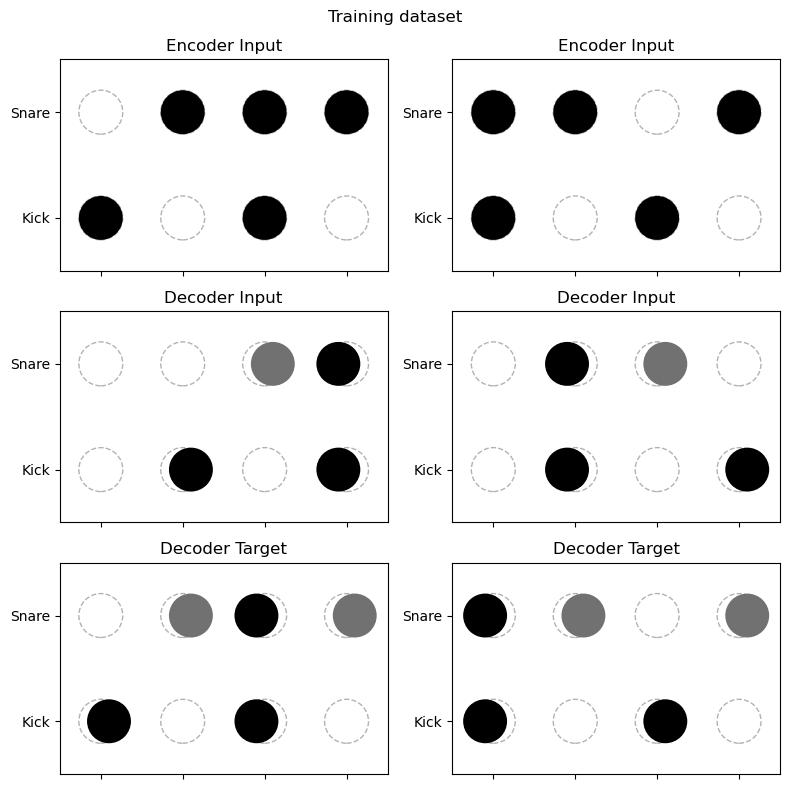

In [ ]:
# Training example
# Dataset shape: (batch, seq_len, instrument, hov=3)
dataset_input = torch.tensor([
    [
        [[1.0, 0.0, 1.0], [0.0, 0.0, 0.0]],
        [[0.0, 0.0, 0.0], [1.0, 0.0, 1.0]],
        [[1.0, 0.0, 1.0], [1.0, 0.0, 1.0]],
        [[0.0, 0.0, 0.0], [1.0, 0.0, 1.0]],
    ],
    [
        [[1.0, 0.0, 1.0], [1.0, 0.0, 1.0]],
        [[0.0, 0.0, 0.0], [1.0, 0.0, 1.0]],
        [[1.0, 0.0, 1.0], [0.0, 0.0, 0.0]],
        [[0.0, 0.0, 0.0], [1.0, 0.0, 1.0]],
    ],
])
dataset_target = torch.tensor([
    [
        [[1.0, 0.1, 0.9], [0.0, 0.0, 0.0]],
        [[0.0, 0.0, 0.0], [1.0, 0.1, 0.5]],
        [[1.0, -0.1, 0.9], [1.0, -0.1, 0.9]],
        [[0.0, 0.0, 0.0], [1.0, 0.1, 0.5]],
    ],
    [
        [[1.0, -0.1, 0.9], [1.0, -0.1, 0.9]],
        [[0.0, 0.0, 0.0], [1.0, 0.1, 0.5]],
        [[1.0, 0.1, 0.9], [0.0, 0.0, 0.0]],
        [[0.0, 0.0, 0.0], [1.0, 0.1, 0.5]],
    ],
])

encoder_input = dataset_input
decoder_input = torch.cat([
    torch.zeros(2, 1, 2, 3),  # Start token
    dataset_target[:, :-1]  # Shift right along the seq_len dimension
], dim=1)
decoder_target = dataset_target

# Create a basic optimizer
model = SimpleDequant(4, 2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

eval_epochs = [10, 100, 1000]
eval_encin = encoder_input[0]
eval_decin = decoder_input[0]
eval_dectar = decoder_target[0]
eval_predictions = []

print("Training...")
for epoch in range(1000):
    # use the whole dataset as a single batch
    output = model(encoder_input, decoder_input)
    loss = criterion(output, decoder_target)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.6f}")

    # Run evaluation on certain epochs
    for eval_epoch in eval_epochs:
        if epoch == eval_epoch - 1:
            with torch.no_grad():
                eval_predictions.append(model.forward(eval_encin.unsqueeze(0), eval_decin.unsqueeze(0))[0].detach())



# Plot the dataset
fig, axes = plt.subplots(3, len(dataset_input))
fig.set_size_inches(8, 8)

for encin, decin, dectar, ax1, ax2, ax3 in zip(encoder_input, decoder_input, decoder_target, *axes):
    plot_pattern(encin.numpy(), ax=ax1)
    ax1.set_title("Encoder Input")
    ax1.set_xticklabels([])

    plot_pattern(decin.numpy(), ax=ax2)
    ax2.set_title("Decoder Input")
    ax2.set_xticklabels([])

    plot_pattern(dectar.numpy(), ax=ax3)
    ax3.set_title("Decoder Target")
    ax3.set_xticklabels([])

fig.suptitle("Training dataset")
fig.tight_layout()
fig.savefig("modelv2_dataset.svg")


# Plot the evaluation
fig, (ax1, ax2, ax3, *eval_axes) = plt.subplots(3 + len(eval_epochs))
fig.set_size_inches(6, 10)

plot_pattern(eval_encin.numpy(), ax=ax1)
ax1.set_title("Encoder Input")
ax1.set_xticklabels([])

plot_pattern(eval_decin.numpy(), ax=ax2)
ax2.set_title("Decoder Input")
ax2.set_xticklabels([])

plot_pattern(eval_dectar.numpy(), ax=ax3)
ax3.set_title("Decoder Target")
ax3.set_xticklabels([])
ax3.set_facecolor("#FC7229")
ax3.patch.set_alpha(0.2)

for epoch, prediction, ax in zip(eval_epochs, eval_predictions, eval_axes):
    plot_pattern(prediction.numpy(), ax=ax)
    ax.set_title(f"Target Prediction (after {epoch} epochs)")
    ax.set_xticklabels([])

    if epoch == 1000:
        ax.set_facecolor("#FC7229")
        ax.patch.set_alpha(0.2)

fig.suptitle("Training evaluation")
fig.tight_layout()
fig.savefig("modelv2_evaluation.svg")